In [2]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: /data6/yuzihan/WorkSpace/35-HuaweiCrowdSimulation/HuaweiCrowdSimulationCode


/tmp/ipykernel_67363/1676093024.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


(np.float64(58.41675453186035),
 np.float64(208.5550198173523),
 np.float64(636.2085113525391),
 np.float64(803.0218620300293))

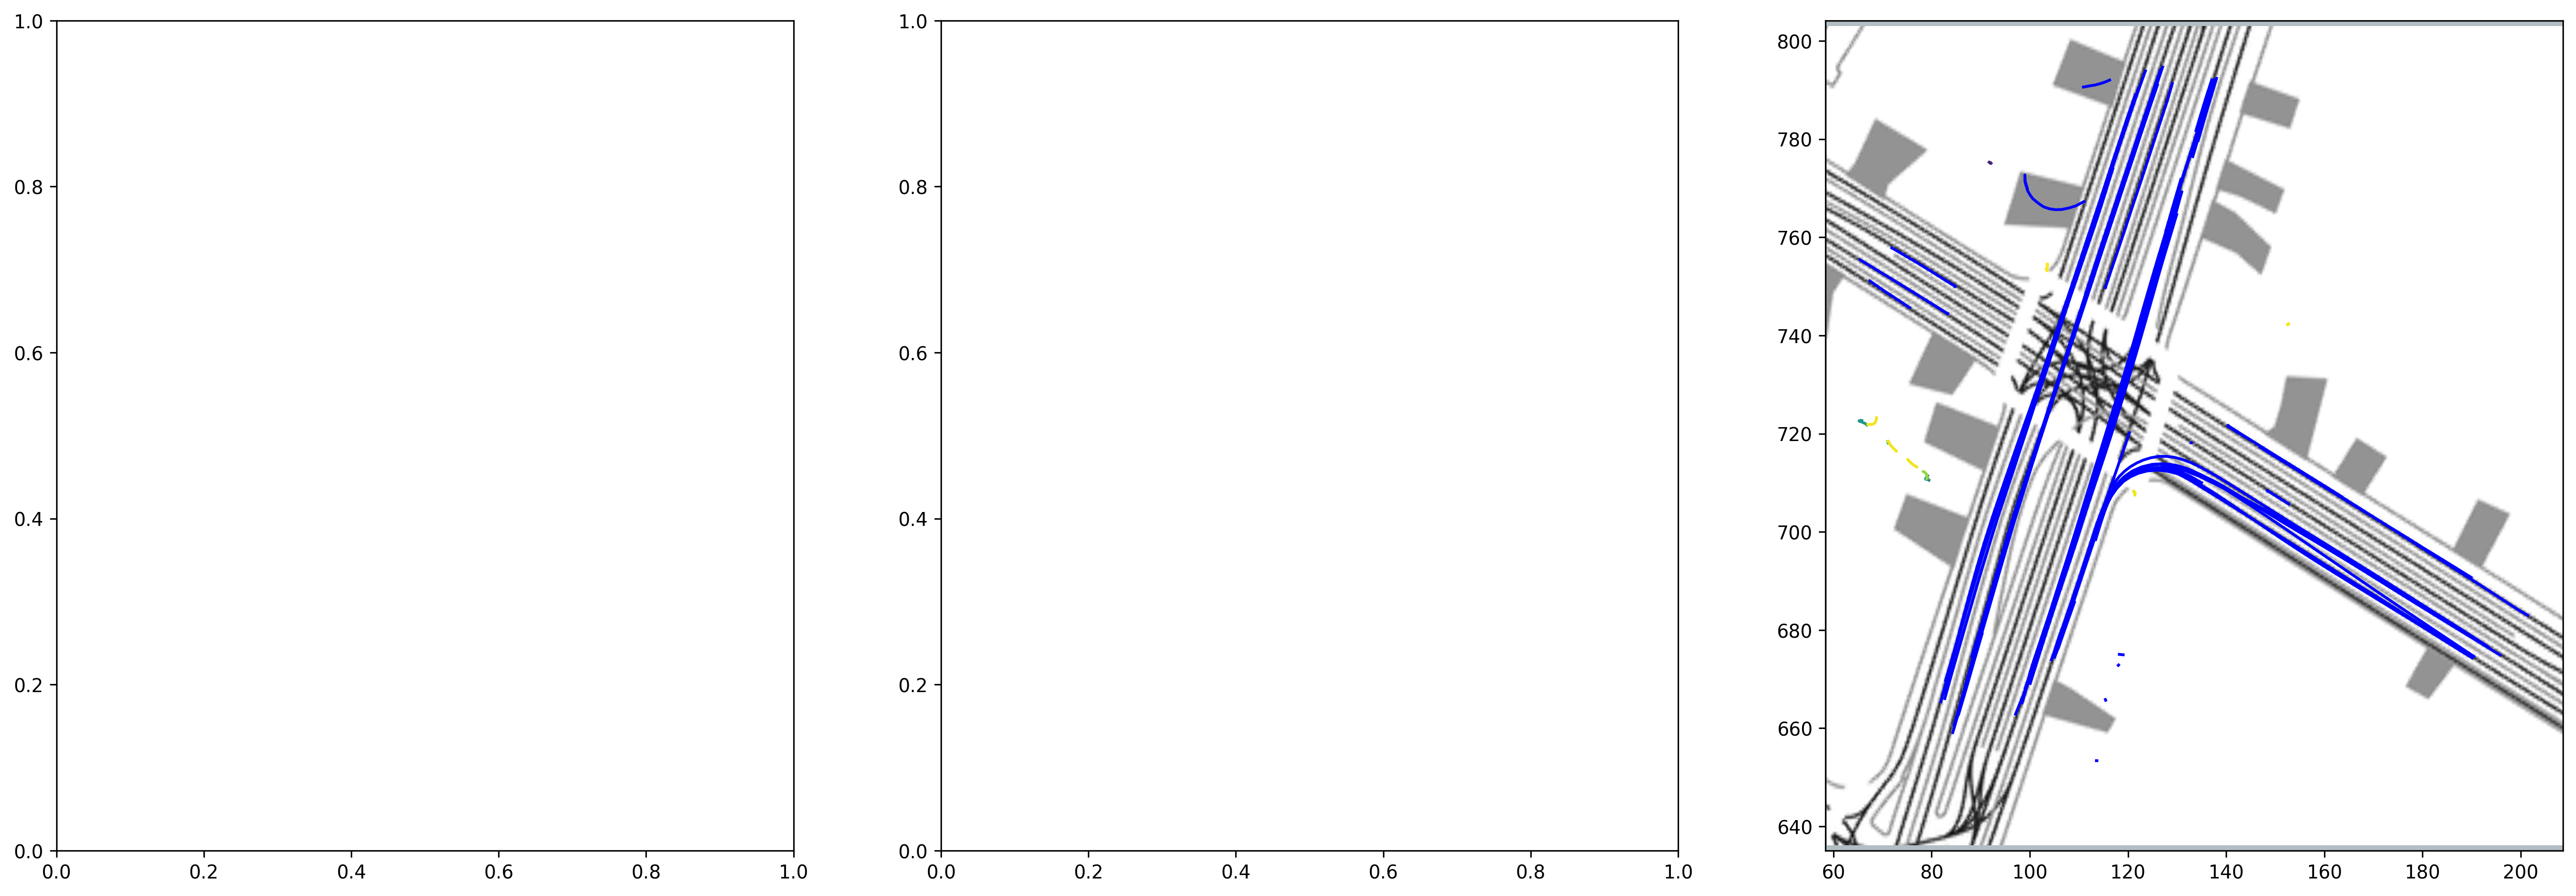

In [9]:
import os
import sys
import torch
import logging
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from tqdm import tqdm
from pathlib import Path
from argparse import Namespace
from src.dataset import BaseDataset, WayMoDataset
from src.utils.homography import calc_homography_mat, affine_transformation, image_to_world
from typing import List

data_path = Path('data/WayMo/Processed/00001_2aa43fad083efbf3/data.csv.gz')
if not data_path.exists():
    raise FileNotFoundError(f"Data path {data_path} not found.")
name = data_path.parent.name

## 读取数据
df_data = pd.read_csv(
    data_path, # center_x center_y center_z length width height heading velocity_x velocity_y f id type
    usecols=["center_x", "center_y", "f", "id", "type"],
)
df_data = df_data.rename(columns={"center_x": "x", "center_y": "y"})  # 第一维向右，第二维向上
df_data['type'] = df_data['type'].replace({ # UNSET, VEHICLE, PEDESTRIAN, CYCLIST, OTHER
    'PEDESTRIAN': 'pedestrian',
    'VEHICLE': 'vehicle',
    'CYCLIST': 'vehicle',
    'UNSET': 'vehicle',
    'OTHER': 'vehicle',
})

## 数据重采样
df_data = WayMoDataset.resample_dataframe(df_data, raw_fps=WayMoDataset.raw_fps, target_fps=2.5)

## 读取地图
map_path = data_path.parent / "map.png"
image = Image.open(map_path).convert('L')
image = ImageOps.invert(image)
h, w = image.size
total_pixels = h * w
max_pixels = 1e5
if total_pixels > max_pixels:
    scale = (max_pixels / total_pixels) ** 0.5
    image = image.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
image = np.array(image)  # (H, W)  第一维向下，第二维向右
h, w = image.shape
xmin0, xmax0, ymin0, ymax0 = np.loadtxt(data_path.parent / 'map_range.txt')
H = calc_homography_mat(
    np.array([[0, 0], [h, 0], [0, w], [h, w]]),
    np.array([[xmin0, ymax0], [xmin0, ymin0], [xmax0, ymax0], [xmax0, ymin0]]),
)
map, xmin, xmax, ymin, ymax = image_to_world(image, H, dot_per_meter=5)  # 第一维向右，第二维向上，即 xy 坐标

# H = calc_homography_mat(
#     np.array([[0, 0], [0, w], [h, 0], [h, w]]),
#     np.array([[xmin0, ymin0], [xmax0, ymin0], [xmin0, ymax0], [xmax0, ymax0]]),
# )
# affine_transformation(np.array([[0, 0], [0, w], [h, 0], [h, w]]), H).round(6)

## 可视化
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=300)
# image0 = np.array(Image.open('data/GC/Demo.jpg'))  # (H, W)  第一维向下，第二维向右
# h, w = image0.shape[:2]
# axes[0].imshow(image0, extent=(0, w, 0, h))  # 第一维向下、第二维向右：直接用 imshow 显示
# for pid, group in df_data.groupby('id'):
#     cmap = plt.cm.get_cmap('viridis')
#     axes[0].plot(group['raw_x'], 1080-group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))  # 第一维向右、第二维向下：将 y 轴翻转后正常 xy 绘制
# axes[0].axis('equal')
# h, w = image.T.shape[:2]
# axes[1].imshow(image.T, extent=(0, w, 0, h), cmap='gray_r')  # 第一维向右，第二维向下：转置后用 imshow 正常显示
# for pid, group in df_data.groupby('id'):
#     cmap = plt.cm.get_cmap('viridis')
#     axes[1].plot(group['raw_x'], 1080-group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))  # 第一维向右、第二维向下：将 y 轴翻转后正常 xy 绘制
# axes[1].axis('equal')
axes[2].imshow(map, origin='lower', extent=(xmin0, xmax0, ymin0, ymax0), cmap='gray_r')  # 第一维向右、第二维向上：需要设置 origin='lower'
for pid, group in df_data.groupby('id'):
    cmap = plt.cm.get_cmap('viridis')
    color = cmap(group['f'].max() / df_data['f'].max())
    if group['type'].iloc[0] == 'vehicle':
        color = 'blue'
    axes[2].plot(group['x'], group['y'], color=color)
axes[2].set_facecolor('#b2bec3')
axes[2].axis('equal')